## RUL Regression

This notebook predicts the Remaining Useful Life (RUL) of turbofan engines.

Unlike the classification models, which predict whether an engine is likely to fail soon, this regression task predicts the approximate number
of operating cycles remaining before failure.

The same time-series feature engineering and engine-wise train-validation strategy used in the classification stage are retained.

In [1]:
#Load the data and recreate the required features
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

# Load FD001 training data
columns = (
    ["engine_id", "cycle"]
    + ["setting_1", "setting_2", "setting_3"]
    + [f"sensor_{i}" for i in range(1, 22)]
)

train = pd.read_csv(
    "CMAPSSData/train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns
)

# Create RUL
train["RUL"] = (
    train.groupby("engine_id")["cycle"]
    .transform("max") - train["cycle"]
)

# Remove constant sensors
constant_sensors = [
    "sensor_1",
    "sensor_5",
    "sensor_10",
    "sensor_16",
    "sensor_18",
    "sensor_19"
]

train_clean = train.drop(columns=constant_sensors)

# Sensors used for feature engineering
feature_sensors = [
    col for col in train_clean.columns
    if col.startswith("sensor_")
]

# Create engineered features
feature_data = train_clean.copy()

for sensor in feature_sensors:

    feature_data[f"{sensor}_rolling_mean"] = (
        feature_data.groupby("engine_id")[sensor]
        .transform(
            lambda x: x.rolling(window=5, min_periods=1).mean()
        )
    )

    feature_data[f"{sensor}_rolling_std"] = (
        feature_data.groupby("engine_id")[sensor]
        .transform(
            lambda x: x.rolling(window=5, min_periods=1).std()
        )
    )

    feature_data[f"{sensor}_delta"] = (
        feature_data.groupby("engine_id")[sensor].diff()
    )

print("Feature data shape:", feature_data.shape)

Feature data shape: (20631, 66)


In [2]:
#Engine wise train/validation split
engine_ids = feature_data["engine_id"].unique()

train_engines, val_engines = train_test_split(
    engine_ids,
    test_size=0.20,
    random_state=42
)

train_data = feature_data[
    feature_data["engine_id"].isin(train_engines)
].copy()

val_data = feature_data[
    feature_data["engine_id"].isin(val_engines)
].copy()

print("Training engines:", train_data["engine_id"].nunique())
print("Validation engines:", val_data["engine_id"].nunique())

print("Training shape:", train_data.shape)
print("Validation shape:", val_data.shape)

Training engines: 80
Validation engines: 20
Training shape: (16561, 66)
Validation shape: (4070, 66)


In [3]:
#Seperate X and y
X_train = train_data.drop(
    columns=["engine_id", "RUL"]
)

y_train = train_data["RUL"]

X_val = val_data.drop(
    columns=["engine_id", "RUL"]
)

y_val = val_data["RUL"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (16561, 64)
y_train: (16561,)
X_val: (4070, 64)
y_val: (4070,)


In [4]:
# Check missing values
print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_val:", X_val.isnull().sum().sum())

Missing values in X_train: 2400
Missing values in X_val: 600


In [5]:
# Check how many rows contain missing values
print("Rows with missing values in X_train:",
      X_train.isnull().any(axis=1).sum())

print("Rows with missing values in X_val:",
      X_val.isnull().any(axis=1).sum())

Rows with missing values in X_train: 80
Rows with missing values in X_val: 20


In [6]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_val_imputed = imputer.transform(X_val)

print("X_train imputed shape:", X_train_imputed.shape)
print("X_val imputed shape:", X_val_imputed.shape)

X_train imputed shape: (16561, 64)
X_val imputed shape: (4070, 64)


In [25]:
import joblib

joblib.dump(imputer, "rul_imputer.pkl")

print("Imputer saved successfully.")

Imputer saved successfully.


In [7]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_reg.fit(X_train_imputed, y_train)

print("Random Forest RUL regression training completed.")

Random Forest RUL regression training completed.


In [8]:
# Predict RUL on validation data

y_pred_rf_reg = rf_reg.predict(X_val_imputed)

print("First 20 actual RUL values:")
print(y_val.values[:20])

print("\nFirst 20 predicted RUL values:")
print(y_pred_rf_reg[:20])

First 20 actual RUL values:
[191 190 189 188 187 186 185 184 183 182 181 180 179 178 177 176 175 174
 173 172]

First 20 predicted RUL values:
[234.74  245.83  232.455 217.835 221.745 210.12  215.595 194.71  188.44
 181.64  205.09  201.53  196.585 192.9   191.43  183.185 188.67  197.535
 198.305 196.385]


In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(y_val, y_pred_rf_reg)

rmse_rf = np.sqrt(
    mean_squared_error(y_val, y_pred_rf_reg)
)

r2_rf = r2_score(y_val, y_pred_rf_reg)

print("Random Forest RUL Regression Results")
print("------------------------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest RUL Regression Results
------------------------------------
MAE : 23.5162972972973
RMSE: 31.889195161668287
R²  : 0.7640649613000275


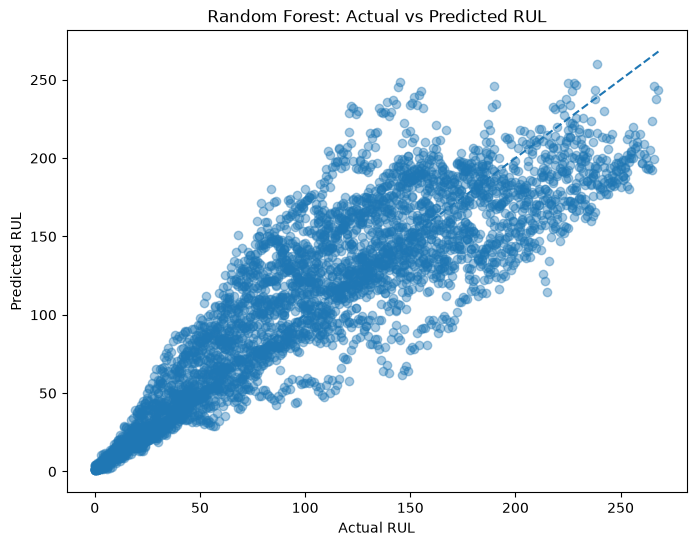

In [10]:
#  Actual Vs Predicted RUL visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_val,
    y_pred_rf_reg,
    alpha=0.4
)

# Perfect prediction line
plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    linestyle="--"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Random Forest: Actual vs Predicted RUL")

plt.show()

## Observation

The predicted RUL values generally follow the diagonal reference line, indicating that the Random Forest model captures the relationship between
sensor features and Remaining Useful Life.

However, the predictions show noticeable dispersion around the reference line, particularly at higher RUL values. This indicates that the model still makes substantial prediction errors for some engines.

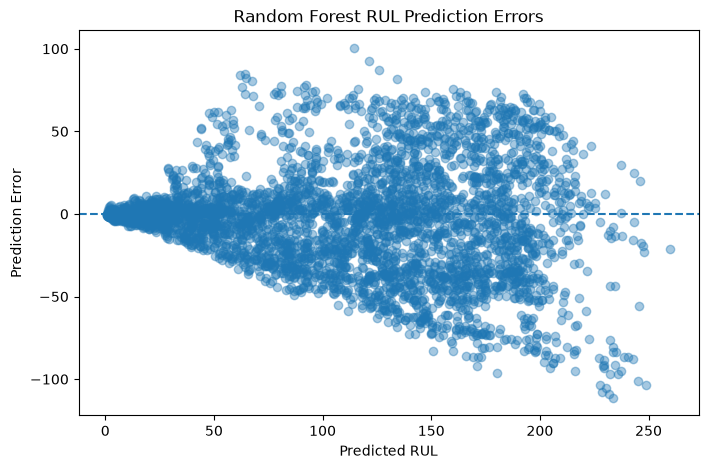

In [11]:
# Calculate prediction errors

errors_rf = y_val - y_pred_rf_reg

plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred_rf_reg,
    errors_rf,
    alpha=0.4
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted RUL")
plt.ylabel("Prediction Error")
plt.title("Random Forest RUL Prediction Errors")

plt.show()

## Residual Analysis

The residual plot shows that prediction errors are distributed around the zero-error line but with considerable variation, particularly at higher
predicted RUL values.

This indicates that the Random Forest model captures the overall RUL relationship but its prediction error is not uniform across all RUL ranges.

In [12]:
#RUL Regression with another model
from sklearn.svm import SVR

In [17]:
from sklearn.preprocessing import StandardScaler

scaler_svr = StandardScaler()

X_train_svr = scaler_svr.fit_transform(X_train_imputed)
X_val_svr = scaler_svr.transform(X_val_imputed)

print("X_train_svr shape:", X_train_svr.shape)
print("X_val_svr shape:", X_val_svr.shape)

X_train_svr shape: (16561, 64)
X_val_svr shape: (4070, 64)


In [18]:
svr_reg = SVR(
    kernel="rbf",
    C=10,
    epsilon=0.1
)

svr_reg.fit(X_train_svr, y_train)

print("SVM RUL regression training completed.")

SVM RUL regression training completed.


In [19]:
# Predict RUL on validation data

y_pred_svr = svr_reg.predict(X_val_svr)

print("First 20 SVR RUL predictions:")
print(y_pred_svr[:20])

First 20 SVR RUL predictions:
[208.2441331  161.15965586 171.81148648 174.83868905 184.9819461
 175.24801104 185.11026189 164.9533081  181.75610944 183.05145019
 168.08127883 194.11433011 170.80359968 165.93592522 172.47012645
 192.65471384 189.67042629 181.15162629 187.02964713 173.14149645]


In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_svr = mean_absolute_error(y_val, y_pred_svr)

rmse_svr = np.sqrt(
    mean_squared_error(y_val, y_pred_svr)
)

r2_svr = r2_score(y_val, y_pred_svr)

print("SVM RUL Regression Results")
print("--------------------------")
print("MAE :", mae_svr)
print("RMSE:", rmse_svr)
print("R²  :", r2_svr)

SVM RUL Regression Results
--------------------------
MAE : 22.49969128079315
RMSE: 30.369896985181953
R²  : 0.7860107465993486


In [21]:
#Model comparison
rul_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "SVR"
    ],
    "MAE": [
        mae_rf,
        mae_svr
    ],
    "RMSE": [
        rmse_rf,
        rmse_svr
    ],
    "R2": [
        r2_rf,
        r2_svr
    ]
})

rul_comparison

,Model,MAE,RMSE,R2
0,Random Forest,23.516297,31.889195,0.764065
1,SVR,22.499691,30.369897,0.786011


In [22]:
import joblib

joblib.dump(rf_reg, "rf_rul_model.pkl")

print("Random Forest RUL model saved successfully.")

Random Forest RUL model saved successfully.


In [23]:
X_val_imputed_df = pd.DataFrame(
    X_val_imputed,
    columns=X_val.columns
)

X_val_imputed_df.to_csv(
    "X_val_imputed.csv",
    index=False
)

print("Validation data saved successfully.")
print("Shape:", X_val_imputed_df.shape)

Validation data saved successfully.
Shape: (4070, 64)


In [24]:
import os

print(os.path.exists("rf_rul_model.pkl"))
print(os.path.exists("X_val_imputed.csv"))

True
True


In [26]:
import joblib
import os

print("Model type:", type(rf_reg))

new_model_path = "rf_rul_model_joblib.pkl"

joblib.dump(
    rf_reg,
    new_model_path,
    compress=3
)

print("New model saved successfully.")
print("File size:", os.path.getsize(new_model_path), "bytes")

Model type: <class 'sklearn.ensemble._forest.RandomForestRegressor'>
New model saved successfully.
File size: 50586560 bytes


In [27]:
import joblib

test_model = joblib.load("rf_rul_model_joblib.pkl")

print("✅ Model loaded successfully!")
print("Model type:", type(test_model))
print("Number of estimators:", test_model.n_estimators)

✅ Model loaded successfully!
Model type: <class 'sklearn.ensemble._forest.RandomForestRegressor'>
Number of estimators: 200


In [28]:
import joblib
import os

print("Imputer type:", type(imputer))

new_imputer_path = "rul_imputer_joblib.pkl"

joblib.dump(
    imputer,
    new_imputer_path,
    compress=3
)

print("New imputer saved successfully.")
print(
    "File size:",
    os.path.getsize(new_imputer_path),
    "bytes"
)

Imputer type: <class 'sklearn.impute._base.SimpleImputer'>
New imputer saved successfully.
File size: 1171 bytes


In [29]:
import joblib

test_imputer = joblib.load("rul_imputer_joblib.pkl")

print("✅ Imputer loaded successfully!")
print("Imputer type:", type(test_imputer))
print("Strategy:", test_imputer.strategy)

✅ Imputer loaded successfully!
Imputer type: <class 'sklearn.impute._base.SimpleImputer'>
Strategy: median
